In [1]:
import numpy as np
import finufft
import matplotlib.pyplot as pl

pi = np.pi

## Comparison with FFT - uniform sampling

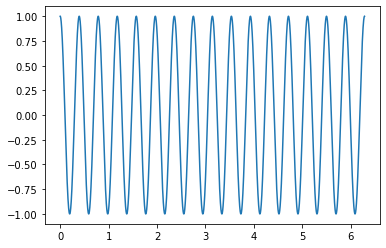

In [2]:
points = 2**16
t = np.linspace(0, 2*pi, points, endpoint=False)
omega = 16
signal = np.real(1*np.exp(1j*omega*t))

pl.plot(t, signal)

Text(0.5, 1.0, 'FFT')

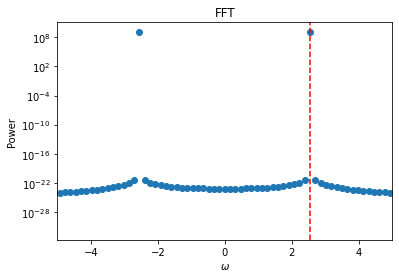

In [3]:
fft_freqs = np.fft.fftshift(np.fft.fftfreq(points, t[1]-t[0]))
fft_amps = np.fft.fftshift(np.fft.fft(signal))
fft_power = abs(fft_amps**2)
pl.semilogy(fft_freqs, fft_power, 'o')
pl.axvline(omega/(2*pi), c='r', ls='--')
pl.xlim(-5, 5)
pl.xlabel(r'$\omega$')
pl.ylabel('Power')
pl.title("FFT")

Text(0.5, 1.0, 'NUFFT')

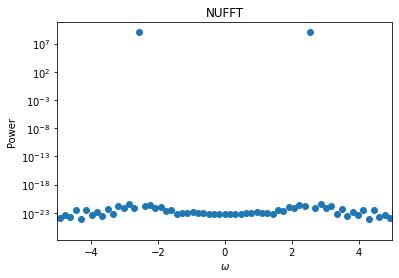

In [4]:
bin_no = points
nufft_freqs = (np.arange(bin_no) - bin_no//2)/(2*pi)
nufft_amps = finufft.nufft1d1(t, signal.astype(complex), bin_no)
nufft_power = abs(nufft_amps**2)
pl.semilogy(nufft_freqs, nufft_power, 'o')
pl.xlim(-5, 5)
pl.xlabel(r'$\omega$')
pl.ylabel('Power')
pl.title("NUFFT")

Text(0.5, 1.0, 'NUFFT vs FFT comparison')

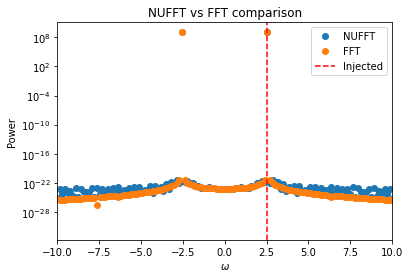

In [5]:
pl.semilogy(nufft_freqs, nufft_power, 'o', label = 'NUFFT')
pl.semilogy(fft_freqs, fft_power, 'o', label = 'FFT')
pl.axvline(omega/(2*pi), c='r', ls='--', label = "Injected")
pl.xlim(-10, 10)
pl.legend()
pl.xlabel(r'$\omega$')
pl.ylabel('Power')
pl.title("NUFFT vs FFT comparison")

## Monochromatic: non-uniform sampling

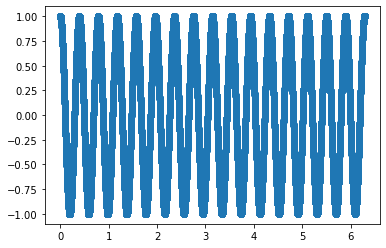

In [6]:
points = 2**16
t_random = np.random.uniform(0, 2*pi, points)
omega = 16
signal = np.real(1*np.exp(1j*omega*t_random))

pl.plot(t_random, signal, 'o')

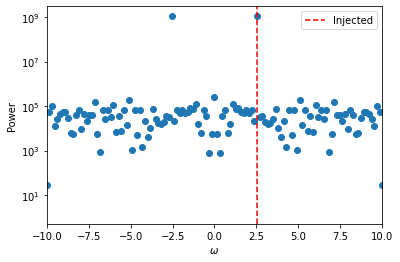

In [7]:
bin_no = points
nufft_freqs = (np.arange(bin_no) - bin_no//2)/(2*pi)
nufft_amps = finufft.nufft1d1(t_random, signal.astype(complex), bin_no)
nufft_power = abs(nufft_amps**2)
pl.semilogy(nufft_freqs, nufft_power, 'o')
pl.xlim(-10, 10)
pl.axvline(omega/(2*pi), c='r', ls='--', label = "Injected")
pl.xlabel(r'$\omega$')
pl.ylabel('Power')
pl.legend()

In [8]:
print("SNR is much worse than uniformly sampled")

SNR is much worse than uniformly sampled


## Resampling with $\dot{f}$

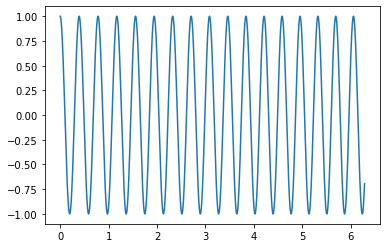

In [43]:
points = 2**16
t = np.linspace(0, 2*pi, points, endpoint=False)
f0 = 16 # rad/s
fdot = 0.1 # rad/s^2 

signal = np.real(1*np.exp(1j*(f0+fdot*t)*t))
pl.plot(t, signal)

# tau = t*(1+fdot/f0*t)
# phi = np.mod(phi, 2*pi)

In [44]:
tau = t*(1+fdot/f0*t)
scale = (2*pi)/(tau[-1]-tau[0])
tau *= scale
start_diff = -tau[0]
tau += start_diff

Notice that the injected f0 is between 2 bins so the power is spread


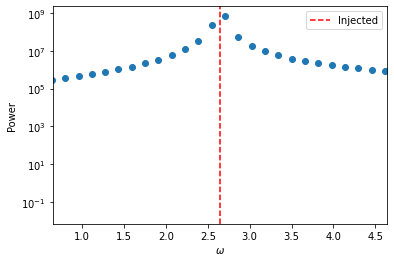

In [45]:
bin_no = points
nufft_freqs = (np.arange(bin_no) - bin_no//2)/(2*pi)
nufft_amps = finufft.nufft1d1(tau, signal.astype(complex), bin_no)
nufft_power = abs(nufft_amps**2)
pl.semilogy(nufft_freqs, nufft_power, 'o')
pl.xlim(f0/(2*pi*scale)-2, f0/(2*pi*scale)+2)
pl.axvline(f0/(2*pi*scale), c='r', ls='--', label = "Injected")
pl.xlabel(r'$\omega$')
pl.ylabel('Power')
pl.legend()
print("Notice that the injected f0 is between 2 bins so the power is spread")

## Fewer bins - todo

In [ ]:
# bin_no just truncates the extremum frequencies?

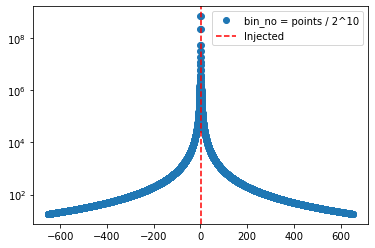

In [48]:
pl.semilogy(nufft_freqs, nufft_power, 'o', label = 'bin_no = points')
pl.xlim(f0/(2*pi*scale)-2, f0/(2*pi*scale)+2)
pl.xlabel(r'$\omega$')
pl.ylabel('Power')

bin_no = points//8
nufft_freqs = (np.arange(bin_no) - bin_no//2)/(2*pi)
nufft_amps = finufft.nufft1d1(tau, signal.astype(complex), bin_no)
nufft_power = abs(nufft_amps**2)
pl.semilogy(nufft_freqs, nufft_power, 'o', label = 'bin_no = points / 2^10')
pl.axvline(f0/(2*pi*scale), c='r', ls='--', label = "Injected")
pl.legend()

In [ ]:
# Todo:
# Checking with fewer bins + type 3